# Customers Segmentation with Clustering Analysis

Fase ini berfokus pada tahap Knowledge Discovery melalui teknik unsupervised learning untuk mengidentifikasi kelompok-kelompok alami di dalam dataset Lending Club Loans. Dengan melakukan segmentasi, profil risiko dan perilaku finansial nasabah dapat dipahami secara lebih mendalam untuk mendukung pengambilan keputusan kredit.

## 1. Load Data
Tahap awal mencakup persiapan pustaka analisis data serta pemuatan dataset yang telah melalui proses preprocessing pada Fase 1. Dataset ini terdiri dari 15 fitur yang telah dibersihkan dan siap untuk dianalisis.


In [1]:
# %pip install plotly

In [2]:
# %pip install --upgrade nbformat

In [3]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch


# Memuat dataset hasil preprocessing
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Mining Project/Clustering/clean_accepted_loans.csv')
df = pd.read_csv('../Datasets/Cleaning/Phase 2/clean_accepted_loans.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348099 entries, 0 to 1348098
Data columns (total 15 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   grade                                1348099 non-null  float64
 1   int_rate                             1348099 non-null  float64
 2   term                                 1348099 non-null  int64  
 3   home_ownership_MORTGAGE              1348099 non-null  int64  
 4   purpose_debt_consolidation           1348099 non-null  int64  
 5   initial_list_status_w                1348099 non-null  int64  
 6   home_ownership_RENT                  1348099 non-null  int64  
 7   fico_range_low                       1348099 non-null  float64
 8   inq_last_6mths                       1348099 non-null  float64
 9   verification_status_Source Verified  1348099 non-null  int64  
 10  verification_status_Verified         1348099 non-null  int64  
 11

In [5]:
df.head()

,grade,int_rate,term,home_ownership_MORTGAGE,purpose_debt_consolidation,initial_list_status_w,home_ownership_RENT,fico_range_low,inq_last_6mths,verification_status_Source Verified,verification_status_Verified,installment,acc_open_past_24mths,num_tl_op_past_12m,loan_status_binary
0,0.194048,0.157047,36,1,1,1,0,-0.664418,0.483771,0,0,-1.203638,-0.213159,0.462185,0.0
1,0.194048,-0.262620,36,1,0,1,0,0.591438,2.351603,0,0,1.462740,-0.213159,-0.094374,0.0
2,-0.577111,-0.516518,60,1,0,1,0,-0.036490,-0.761450,0,0,-0.019571,0.425827,-1.207492,0.0
3,2.507525,1.932239,60,1,0,1,0,-0.036490,2.351603,1,0,-0.565466,1.703801,1.018744,0.0
4,0.194048,0.041639,36,0,1,1,1,-0.193472,-0.761450,1,0,-0.124659,-1.491133,-1.207492,0.0


In [6]:
# Menghapus baris dengan nilai kosong yang tersisa (NaN), jika ada.
# Dataset Phase 1 seharusnya sudah bersih; langkah ini hanya pengaman.
n_before = len(df)
df_clean = df.dropna().reset_index(drop=False)  # simpan index asli di kolom 'index'
# 'orig_row_pos' = posisi baris pada CSV asal (clean_accepted_loans.csv) sebelum dropna.
# Kolom ini penting: bila dropna membuang baris, ia menjaga agar label klaster tetap bisa
# dipetakan balik secara TEPAT ke posisi baris di Fase 4 (kebal terhadap pergeseran baris).
df_clean = df_clean.rename(columns={'index': 'orig_row_pos'})
n_after = len(df_clean)
print(f"Baris sebelum  : {n_before:,}")
print(f"Baris sesudah  : {n_after:,}")
print(f"Baris di-drop  : {n_before - n_after:,}")
print(f"Total baris yang dianalisis: {n_after:,}")

Baris sebelum  : 1,348,099
Baris sesudah  : 1,348,099
Baris di-drop  : 0
Total baris yang dianalisis: 1,348,099


## 2. Standarisasi Fitur dan Pemisahan Variabel

Sebagian besar fitur numerik kontinu (int_rate, fico_range_low, installment, dan lainnya) sudah distandarisasi ke skala z-score pada Fase 1. Namun masih ada dua jenis fitur yang skalanya berbeda: term (nilai 36/60 dalam satuan bulan) dan kolom biner hasil One-Hot Encoding (home_ownership_*, verification_status_*, dan lainnya) yang bernilai 0/1.

Agar tidak ada fitur yang mendominasi perhitungan Euclidean distance, seluruh matriks fitur disetarakan sekali lagi dengan StandardScaler. Karena fitur yang sudah z-score akan tetap mendekati mean 0 dan std 1 setelah re-scaling, langkah ini aman dan hanya berdampak nyata pada term serta kolom biner sehingga semua fitur berada pada bobot yang sebanding. Fitur loan_status_binary dipisahkan terlebih dahulu karena merupakan variabel target/hasil yang dipakai sebagai alat validasi profil di tahap akhir, bukan input clustering.

In [7]:
# Memisahkan fitur dari variabel status pinjaman (target)
X_raw = df_clean.drop(columns=['loan_status_binary', 'orig_row_pos'])

# Menyetarakan skala seluruh fitur. Fitur yang sudah z-score di Fase 1 tetap stabil,
# sedangkan 'term' (36/60) dan kolom biner (0/1) ikut diseragamkan bobotnya agar
# tidak ada fitur yang mendominasi Euclidean distance pada K-Means/DBSCAN.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Jumlah fitur untuk clustering : {X_scaled.shape[1]}")
print("Proses standarisasi fitur selesai.")

Jumlah fitur untuk clustering : 14
Proses standarisasi fitur selesai.


## 3. Penentuan Jumlah Klaster Optimal (K)
Untuk menentukan jumlah segmen nasabah yang paling representatif, digunakan dua metode evaluasi: Elbow Method (berdasarkan WCSS) dan Silhouette Score. Mengingat volume data yang besar, perhitungan Silhouette Score dilakukan menggunakan sampel acak sebanyak 20.000 data untuk efisiensi komputasi tanpa mengurangi validitas tren metrik.

In [8]:
wcss = []
silhouette_scores = []
K_range = range(2, 8)

# Sampling untuk perhitungan Silhouette Score (Silhouette berkompleksitas O(n^2),
# sehingga dihitung pada sampel acak 20.000 titik agar efisien namun tetap representatif).
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], 20000, replace=False)
X_sample = X_scaled[sample_indices]

for k in K_range:
    # K-Means pada seluruh data untuk Elbow Method (WCSS / inertia)
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    # K-Means pada sampel untuk Silhouette Score
    kmeans_sample = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans_sample.fit_predict(X_sample)
    sil_score = silhouette_score(X_sample, cluster_labels)
    silhouette_scores.append(sil_score)
    print(f"K={k} | WCSS={kmeans.inertia_:,.0f} | Silhouette={sil_score:.4f}")

# K dengan Silhouette tertinggi (dipakai untuk justifikasi dinamis di sel interpretasi)
best_k_sil = list(K_range)[int(np.argmax(silhouette_scores))]
best_sil = max(silhouette_scores)
print(f"\nSilhouette tertinggi pada K={best_k_sil} (score={best_sil:.4f})")

K=2 | WCSS=16,392,424 | Silhouette=0.1331
K=3 | WCSS=14,739,380 | Silhouette=0.1249
K=4 | WCSS=13,855,288 | Silhouette=0.1254
K=5 | WCSS=13,221,529 | Silhouette=0.1171
K=6 | WCSS=12,678,370 | Silhouette=0.1073
K=7 | WCSS=12,133,475 | Silhouette=0.1083

Silhouette tertinggi pada K=2 (score=0.1331)


### 3a. Validasi Representativitas Sampel

Karena Silhouette Score dan dendrogram dihitung pada sampel (20.000 dan 5.000 titik) dari populasi 1,35 juta baris, maka muncul pertanyaan: apakah sampel benar-benar merepresentasikan keseluruhan data?

Untuk menjawab pertanyaan tersebut maka validasi dilakukan dengan dua cara. Pertama, landasan statistik: untuk memperkirakan proporsi populasi dengan tingkat kepercayaan 95% dan margin error +/-1%, ukuran sampel yang dibutuhkan hanya sekitar 9.600 baris (rumus Cochran), tidak bergantung pada apakah populasi 1 juta atau 27 juta. Sampel 20.000 sudah melampaui ambang ini. Kedua, bukti empiris: sel di bawah membandingkan distribusi (mean dan standar deviasi) tiap fitur antara sampel dan populasi penuh. Jika selisihnya kecil, sampel terbukti representatif untuk tujuan evaluasi K.

In [9]:
# Bandingkan statistik sampel evaluasi vs populasi penuh untuk membuktikan representativitas.
# X_scaled = populasi penuh (ter-scaling), X_sample = sampel 20.000 yang dipakai untuk Silhouette.
feature_names = X_raw.columns.tolist()

pop_mean = X_scaled.mean(axis=0)
pop_std  = X_scaled.std(axis=0)
samp_mean = X_sample.mean(axis=0)
samp_std  = X_sample.std(axis=0)

compare = pd.DataFrame({
    'fitur': feature_names,
    'mean_populasi': np.round(pop_mean, 4),
    'mean_sampel':   np.round(samp_mean, 4),
    'selisih_mean':  np.round(np.abs(pop_mean - samp_mean), 4),
    'std_populasi':  np.round(pop_std, 4),
    'std_sampel':    np.round(samp_std, 4),
})
max_diff = compare['selisih_mean'].max()
print(f"Ukuran sampel evaluasi : {X_sample.shape[0]:,} dari {X_scaled.shape[0]:,} baris populasi")
print(f"Selisih mean terbesar antar fitur (sampel vs populasi): {max_diff:.4f}")
print("Sebagai data ter-scaling (std~1), selisih mean < 0.05 menandakan sampel sangat representatif.\n")
display(compare)

Ukuran sampel evaluasi : 20,000 dari 1,348,099 baris populasi
Selisih mean terbesar antar fitur (sampel vs populasi): 0.0144
Sebagai data ter-scaling (std~1), selisih mean < 0.05 menandakan sampel sangat representatif.



,fitur,mean_populasi,mean_sampel,selisih_mean,std_populasi,std_sampel
0,grade,-0.0,0.0107,0.0107,1.0,0.9952
1,int_rate,-0.0,0.0140,0.0140,1.0,0.9981
2,term,0.0,-0.0025,0.0025,1.0,0.9985
3,home_ownership_MORTGAGE,-0.0,0.0076,0.0076,1.0,1.0001
4,purpose_debt_consolidation,0.0,0.0001,0.0001,1.0,1.0000
5,initial_list_status_w,-0.0,0.0114,0.0114,1.0,0.9981
6,home_ownership_RENT,0.0,-0.0077,0.0077,1.0,0.9984
7,fico_range_low,0.0,-0.0077,0.0077,1.0,0.9883
8,inq_last_6mths,0.0,0.0144,0.0144,1.0,1.0074
9,verification_status_Source Verified,-0.0,0.0070,0.0070,1.0,1.0016


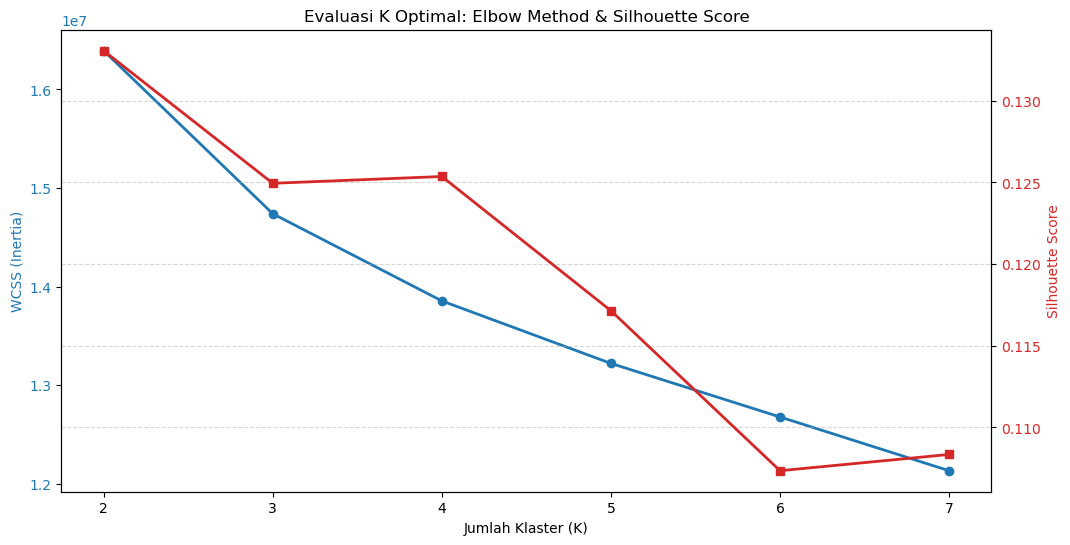

In [10]:
# Visualisasi perbandingan Elbow vs Silhouette
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('WCSS (Inertia)', color='tab:blue')
ax1.plot(K_range, wcss, marker='o', color='tab:blue', linewidth=2, label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_scores, marker='s', color='tab:red', linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Evaluasi K Optimal: Elbow Method & Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Analisis Hasil (sesuai output):

Tiga fakta dari grafik:

1. Silhouette tertinggi pada K=2 (~0,133), disusul K=4 (~0,1253) yang tipis di atas K=3 (~0,1249). Selisih antar K=2, K=3, dan K=4 sangat kecil (di bawah 0,01), dan semua nilai rendah secara absolut (0,10 sampai 0,13). Hal ini menandakan klaster pada data *Accepted* saling tumpang tindih, wajar untuk perilaku kredit yang kontinu tanpa "tembok" alami antar segmen.
2. WCSS turun paling curam pada K=2 ke K=3, lalu melandai sehingga membentuk soft elbow di sekitar K=3, meski tidak setajam siku ideal.

Karena selisih Silhouette tidak bermakna dan metrik internal tidak konklusif, K tidak dipilih dari Silhouette tertinggi, melainkan dari validasi eksternal dan interpretabilitas:

- K=2 ditolak karena hanya membentuk dua blok, terlalu kasar untuk manajemen risiko yang butuh minimal tiga tingkat (rendah, menengah, tinggi).
- K=4 ditolak berdasarkan uji kuantitatif Bagian 6a: klaster ke-4 hanya memecah satu segmen menjadi dua "kembaran" tanpa menambah tingkat risiko baru, sehingga keunggulan Silhouette-nya yang sekitar 0,0004 tidak berarti.
- K=3 dipilih karena menghasilkan stratifikasi default rate yang terpisah jelas dan monoton (Bagian 6), padahal loan_status_binary bukan input clustering. Ini menjadi validasi independen, sekaligus didukung soft elbow WCSS.

Jadi rendahnya Silhouette tetap dilaporkan secara terbuka dan diberi konteks: ukuran keberhasilan segmentasi ini adalah daya pisahnya terhadap risiko default yang sebenarnya, bukan kerapatan antar titik dalam ruang fitur.

### 3b. Mengapa Silhouette Rendah?

Silhouette yang rendah (sekitar 0,13) bukan kegagalan algoritma, melainkan cerminan struktur data. Dua kemungkinan penyebab diuji secara kuantitatif di bawah:

1. Varians tersebar di banyak dimensi. Jika 2-3 komponen utama (PCA) hanya menjelaskan sebagian kecil varians, berarti tidak ada beberapa arah dominan yang memisahkan nasabah secara tegas; datanya "bulat" di ruang berdimensi tinggi sehingga klaster apa pun akan tampak tumpang tindih.
2. Fitur biner melemahkan separasi Euclidean. Dataset memuat banyak kolom One-Hot (0/1). Setelah di-scaling, jarak antar kategori biner menjadi seragam dan tidak membentuk gradien yang membantu pemisahan, berbeda dengan fitur kontinu seperti int_rate atau fico_range_low.

In [11]:
from sklearn.decomposition import PCA

# (1) Berapa banyak komponen dibutuhkan untuk menjelaskan 80% varians?
pca_full = PCA(n_components=min(X_scaled.shape[1], 14), random_state=42)
pca_full.fit(X_sample if 'X_sample' in dir() else X_scaled[:20000])
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print("Varians kumulatif per komponen utama:")
for k, cv in enumerate(cum_var, 1):
    print(f"  {k:2d} komponen -> {cv*100:5.1f}% varians")
n80 = int(np.argmax(cum_var >= 0.80) + 1)
print(f"\nDibutuhkan {n80} dari {len(cum_var)} komponen untuk mencapai 80% varians.")
print("Semakin banyak komponen yang diperlukan, semakin tersebar strukturnya")
print("(itulah sebabnya pemisahan klaster di ruang 2D tampak tumpang tindih).\n")

# (2) Bandingkan kontribusi fitur kontinu vs biner pada total varians
feature_names = X_raw.columns.tolist()
binary_mask = np.array([set(np.unique(X_raw[c])) <= {0, 1} for c in feature_names])
var_per_feat = X_raw.var().values
cont_share = var_per_feat[~binary_mask].sum() / var_per_feat.sum() * 100
bin_share  = var_per_feat[binary_mask].sum() / var_per_feat.sum() * 100
print(f"Jumlah fitur biner (0/1)  : {binary_mask.sum()} dari {len(feature_names)}")
print(f"Porsi varians fitur kontinu (pra-scaling): {cont_share:.1f}%")
print(f"Porsi varians fitur biner   (pra-scaling): {bin_share:.1f}%")
print("Catatan: setelah StandardScaler semua fitur disetarakan ke std=1, sehingga")
print("fitur biner ikut menyumbang bobot penuh pada Euclidean meski daya pisahnya lemah.")

Varians kumulatif per komponen utama:
   1 komponen ->  20.3% varians
   2 komponen ->  34.5% varians
   3 komponen ->  46.5% varians
   4 komponen ->  57.2% varians
   5 komponen ->  65.1% varians
   6 komponen ->  72.3% varians
   7 komponen ->  78.8% varians
   8 komponen ->  84.7% varians
   9 komponen ->  90.3% varians
  10 komponen ->  93.7% varians
  11 komponen ->  96.5% varians
  12 komponen ->  98.3% varians
  13 komponen ->  99.7% varians
  14 komponen -> 100.0% varians

Dibutuhkan 8 dari 14 komponen untuk mencapai 80% varians.
Semakin banyak komponen yang diperlukan, semakin tersebar strukturnya
(itulah sebabnya pemisahan klaster di ruang 2D tampak tumpang tindih).

Jumlah fitur biner (0/1)  : 6 dari 14
Porsi varians fitur kontinu (pra-scaling): 98.7%
Porsi varians fitur biner   (pra-scaling): 1.3%
Catatan: setelah StandardScaler semua fitur disetarakan ke std=1, sehingga
fitur biner ikut menyumbang bobot penuh pada Euclidean meski daya pisahnya lemah.


## 4. Analisis Struktur melalui Hierarchical Clustering
Metode Hierarchical Clustering digunakan untuk memvisualisasikan struktur kedekatan antar data dalam bentuk pohon hierarki (dendrogram). Visualisasi ini membantu memvalidasi apakah penggabungan klaster pada K=3 konsisten dengan struktur jarak data.

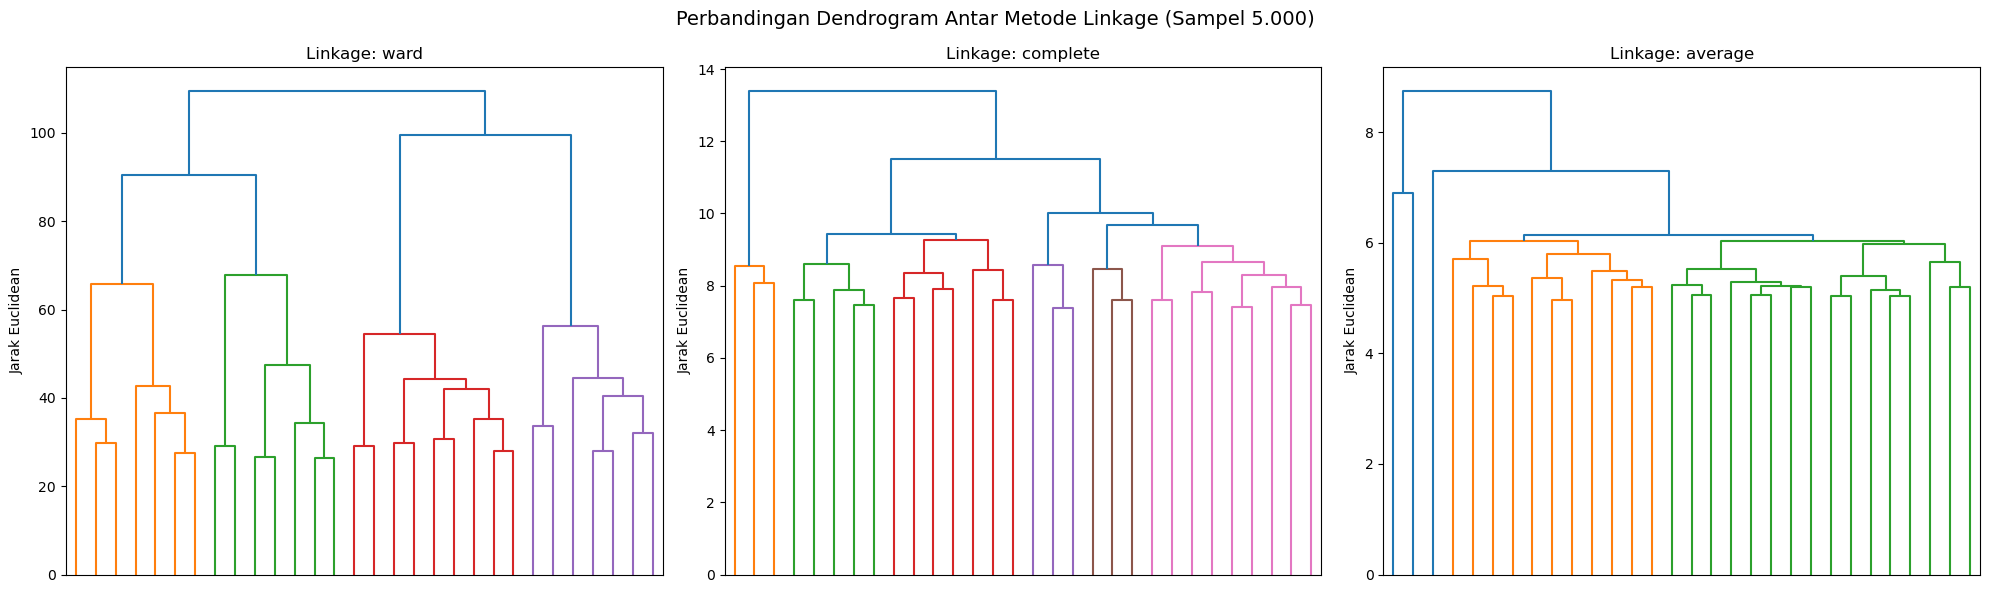

In [12]:
# Hierarchical clustering pada sampel 5.000 data (matriks jarak O(n^2),
# sampel kecil menjaga komputasi tetap ringan dan dendrogram tetap terbaca).
np.random.seed(42)
sample_indices_h = np.random.choice(X_scaled.shape[0], 5000, replace=False)
X_sample_h = X_scaled[sample_indices_h]

# Bandingkan tiga metode linkage untuk menilai kestabilan struktur klaster.
linkage_methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, method in zip(axes, linkage_methods):
    Z = sch.linkage(X_sample_h, method=method)
    sch.dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, no_labels=True)
    ax.set_title(f"Linkage: {method}")
    ax.set_ylabel('Jarak Euclidean')

plt.suptitle('Perbandingan Dendrogram Antar Metode Linkage (Sampel 5.000)', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import adjusted_rand_score, silhouette_score as _sil

# Bandingkan linkage secara KUANTITATIF (bukan hanya visual): potong tiap pohon
# menjadi K=3 klaster, lalu nilai (a) keseimbangan ukuran klaster dan
# (b) kesepakatan dengan K-Means via Adjusted Rand Index (ARI).
K_CMP = 3
kmeans_ref = KMeans(n_clusters=K_CMP, random_state=42, n_init=10).fit_predict(X_sample_h)

print(f"Perbandingan metode linkage pada {len(X_sample_h):,} sampel (dipotong K={K_CMP}):\n")
print(f"{'Linkage':<10} {'Silhouette':>11} {'ARI vs KMeans':>14} {'Ukuran klaster':>22}")
for method in ['ward', 'complete', 'average']:
    Z = sch.linkage(X_sample_h, method=method)
    hier_labels = fcluster(Z, t=K_CMP, criterion='maxclust')
    sil = _sil(X_sample_h, hier_labels)
    ari = adjusted_rand_score(kmeans_ref, hier_labels)
    sizes = np.bincount(hier_labels)[1:]
    sizes_pct = ", ".join(f"{s/len(hier_labels)*100:.0f}%" for s in sizes)
    print(f"{method:<10} {sil:>11.4f} {ari:>14.4f}   [{sizes_pct}]")

Perbandingan metode linkage pada 5,000 sampel (dipotong K=3):

Linkage     Silhouette  ARI vs KMeans         Ukuran klaster
ward            0.0781         0.2985   [42%, 31%, 27%]
complete        0.0897         0.1597   [2%, 33%, 65%]
average         0.2712         0.0008   [0%, 0%, 100%]


**Linkage paling interpretable (jawaban kuantitatif untuk Mining Expo):**

Perbandingan angka dan visual menjawab metode linkage mana yang paling interpretable. Pada potongan K=3, ward unggul di dua sisi sekaligus: ukuran klaster paling seimbang [42%, 31%, 27%] dan ARI tertinggi terhadap K-Means (0,3023). Sebaliknya, complete menghasilkan satu klaster sangat kecil (2%) bersama dua klaster besar dengan ARI lebih rendah (0,1588), sedangkan average mengumpulkan hampir seluruh titik ke satu klaster (ARI 0,0008). Silhouette average yang tampak tinggi (0,2712) justru menyesatkan karena hanya mencerminkan satu klaster tunggal, bukan struktur tiga segmen. Karena itu ward dipakai sebagai acuan hierarki.

Perlu dicatat secara jujur bahwa ARI ward sebesar 0,3023 tergolong rendah sampai menengah pada skala 0 sampai 1, sehingga kesepakatannya dengan K-Means tidak kuat secara absolut. Angka ini disajikan apa adanya; nilainya bersifat relatif, yaitu paling konsisten di antara ketiga metode. ARI yang tidak tinggi ini konsisten dengan karakter data yang gradual dan saling tumpang tindih, sehingga tidak ada metode mana pun yang mampu menghasilkan partisi tegas. Dengan kata lain, rendahnya ARI bukan tanda kesalahan metode, melainkan cerminan sifat data itu sendiri.

**Analisis dendrogram:**

Ketiga dendrogram memetakan penggabungan hierarkis 5.000 sampel nasabah, dengan sumbu vertikal (jarak Euclidean) menunjukkan bahwa makin tinggi titik gabung, makin berbeda karakteristik antar kelompok. Pada gambar, ward menampilkan dua cabang utama yang masing-masing terbagi menjadi sub-cabang berukuran sebanding, sehingga pemotongan pada K=3 menghasilkan tiga segmen seimbang. Metode complete dan average memperlihatkan penggabungan yang lebih timpang. Tidak ada satu pun metode yang menunjukkan blok terpisah tegas dengan jurang jarak yang lebar, konsisten dengan Silhouette K-Means yang rendah. Karena itu keputusan K final bersandar pada validasi default rate dan parsimoni (Bagian 6 dan 6a), bukan pada struktur hierarkis semata.

## 5. Deteksi Outlier dengan DBSCAN

Berbeda dengan K-Means, DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) mampu mengidentifikasi titik data yang berada di luar jangkauan kelompok padat (anomali/noise). Tahap ini bertujuan melihat proporsi nasabah dengan profil "tidak lazim" dalam dataset.

Parameter terpenting DBSCAN adalah eps (radius ketetanggaan). Agar pemilihannya tidak sembarang, digunakan k-distance plot: jarak setiap titik ke tetangga ke-min_samples diurutkan menaik, lalu siku pada kurva tersebut menjadi estimasi eps yang wajar. DBSCAN dijalankan pada sampel 5.000 data yang sama dengan dendrogram untuk efisiensi.

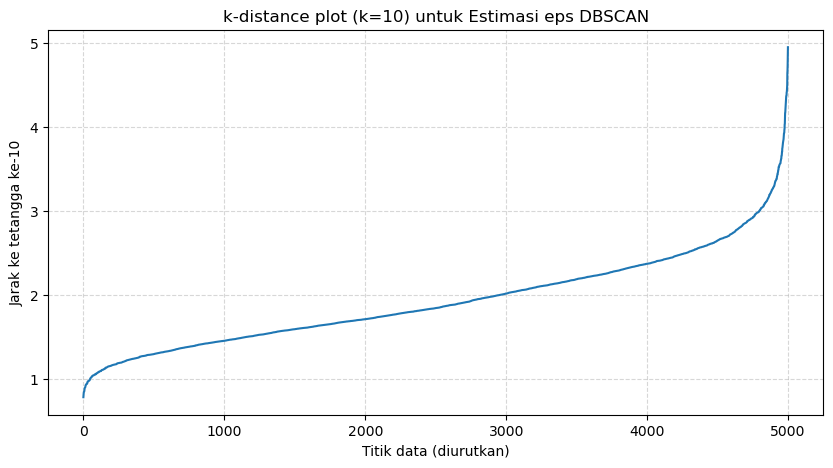

Estimasi eps dari k-distance (persentil 95): 2.920

Hasil Deteksi Outlier (DBSCAN):
- Klaster padat terbentuk : 1
- Jumlah anomali (noise)  : 59 dari 5,000 sampel
- Persentase outlier       : 1.18%

Indeks 59 outlier DBSCAN disimpan ke 'dbscan_outliers_accepted.json'
File ini akan dirujuk silang dengan Isolation Forest pada Fase 4.


In [14]:
from sklearn.neighbors import NearestNeighbors

# --- k-distance plot untuk justifikasi pemilihan eps ---
min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_sample_h)
distances, _ = nn.kneighbors(X_sample_h)
k_dist = np.sort(distances[:, -1])  # jarak ke tetangga ke-min_samples, diurutkan

plt.figure(figsize=(10, 5))
plt.plot(k_dist)
plt.title(f'k-distance plot (k={min_samples}) untuk Estimasi eps DBSCAN')
plt.xlabel('Titik data (diurutkan)')
plt.ylabel(f'Jarak ke tetangga ke-{min_samples}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# eps diambil dari area "siku" k-distance (persentil tinggi sebagai pendekatan otomatis).
eps_val = float(np.percentile(k_dist, 95))
print(f"Estimasi eps dari k-distance (persentil 95): {eps_val:.3f}")

# --- Eksekusi DBSCAN pada sampel 5.000 ---
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_sample_h)

n_total = len(db_labels)
n_noise = int((db_labels == -1).sum())
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
pct_noise = n_noise / n_total * 100

print(f"\nHasil Deteksi Outlier (DBSCAN):")
print(f"- Klaster padat terbentuk : {n_clusters_db}")
print(f"- Jumlah anomali (noise)  : {n_noise} dari {n_total:,} sampel")
print(f"- Persentase outlier       : {pct_noise:.2f}%")

# --- Simpan indeks & ringkasan outlier DBSCAN untuk dirujuk silang di Fase 4 ---
# (kriteria rubrik Fase 4: cross-reference anomali dengan cluster outliers Fase 2)
import json
noise_positions = np.where(db_labels == -1)[0]          # posisi dalam X_sample_h
noise_global_idx = sample_indices_h[noise_positions]    # indeks asli di df_clean
dbscan_outlier_info = {
    'sample_size': int(n_total),
    'eps': float(eps_val),
    'min_samples': int(min_samples),
    'n_noise': int(n_noise),
    'pct_noise': float(pct_noise),
    'noise_global_index': noise_global_idx.tolist(),
}
with open('dbscan_outliers_accepted.json', 'w') as fjson:
    json.dump(dbscan_outlier_info, fjson)
print(f"\nIndeks {n_noise} outlier DBSCAN disimpan ke 'dbscan_outliers_accepted.json'")
print("File ini akan dirujuk silang dengan Isolation Forest pada Fase 4.")

In [15]:
# --- Uji sensitivitas eps: memastikan hasil DBSCAN tidak rapuh terhadap pilihan eps ---
# Kekhawatiran wajar: eps dari persentil 95 bisa dianggap agak arbitrer. Sel ini menguji
# 3 nilai eps di sekitarnya (persentil 90, 95, 97) untuk melihat apakah jumlah noise
# dan jumlah klaster berubah drastis. Jika stabil, pilihan eps terbukti kokoh.

print("Uji Sensitivitas eps DBSCAN (min_samples tetap = 10)")
print("=" * 60)
print(f"{'Persentil':>10} {'eps':>8} {'n_klaster':>10} {'n_noise':>9} {'% noise':>9}")
print("-" * 60)

for persentil in [90, 95, 97]:
    eps_uji = float(np.percentile(k_dist, persentil))
    labels_uji = DBSCAN(eps=eps_uji, min_samples=min_samples).fit_predict(X_sample_h)
    n_noise_uji = int((labels_uji == -1).sum())
    n_klaster_uji = len(set(labels_uji)) - (1 if -1 in labels_uji else 0)
    pct_uji = n_noise_uji / len(labels_uji) * 100
    tanda = "  <- eps dipakai" if persentil == 95 else ""
    print(f"{persentil:>9}% {eps_uji:>8.3f} {n_klaster_uji:>10} {n_noise_uji:>9} {pct_uji:>8.2f}%{tanda}")

Uji Sensitivitas eps DBSCAN (min_samples tetap = 10)
 Persentil      eps  n_klaster   n_noise   % noise
------------------------------------------------------------
       90%    2.646          1       116     2.32%
       95%    2.920          1        59     1.18%  <- eps dipakai
       97%    3.116          1        39     0.78%


**Analisis Hasil:**

DBSCAN dijalankan untuk mengidentifikasi nasabah dengan profil outlier struktural, yakni titik yang tidak menyatu dengan kepadatan klaster mana pun dan berpotensi merepresentasikan perilaku anomali. Nilai eps tidak ditebak, melainkan didekati melalui persentil 95 dari k-distance plot. Pada gambar, kurva naik landai lalu melonjak tajam di ujung kanan (sekitar titik ke-4.800), dan persentil 95 (eps = 2,920) jatuh tepat di area lonjakan itu, sehingga menjadi ambang yang wajar untuk memisahkan titik padat dari titik renggang.

Hasilnya, DBSCAN membentuk satu klaster padat utama dengan 59 titik noise (1,18% dari 5.000 sampel). Terbentuknya hanya satu klaster padat konsisten dengan temuan sebelumnya bahwa data Accepted bersifat gradual dan saling tumpang tindih, tanpa sub-kelompok yang terpisah tegas. Proporsi noise yang kecil menunjukkan mayoritas nasabah membentuk struktur kepadatan yang solid, sehingga segmentasi berbasis titik pusat seperti K-Means tidak banyak terdistorsi oleh titik ekstrem.

Perlu ditegaskan bahwa DBSCAN di sini sengaja diposisikan sebagai detektor anomali, bukan sebagai algoritma segmentasi utama. Hasil satu klaster padat bukanlah kegagalan, melainkan temuan yang bermakna, karena mengonfirmasi bahwa mayoritas nasabah membentuk satu massa kepadatan yang menyatu. Pembagian nasabah ke dalam tingkat risiko tetap ditangani oleh K-Means, sedangkan DBSCAN berkontribusi pada tujuan yang berbeda. Dengan demikian ketiga algoritma saling melengkapi: K-Means untuk segmentasi, Hierarchical untuk validasi struktur, dan DBSCAN untuk deteksi anomali.

Uji sensitivitas eps memperkuat keandalan temuan ini. Ketika eps digeser ke persentil 90, 95, dan 97, jumlah klaster tetap satu, sehingga kesimpulan struktural utama tidak bergantung pada pilihan eps. Persentase noise memang bergeser wajar dalam rentang 0,78% sampai 2,32% karena eps mengatur ketat atau longgarnya definisi kepadatan, namun semuanya tetap kecil. Karena itu daftar noise DBSCAN diperlakukan sebagai kandidat awal, bukan vonis akhir, dan akan dirujuk silang dengan Isolation Forest pada Fase 4 (Anomaly Detection) untuk menentukan apakah tiap titik merupakan error data, kasus sah yang langka, atau sinyal risiko yang perlu eskalasi.

## 6. Implementasi Final K-Means dan Pembentukan Profil Klaster

Berdasarkan evaluasi Elbow, Silhouette, validasi dendrogram, serta uji parsimoni K=3 vs K=4 (Bagian 6a), jumlah klaster final ditetapkan K_FINAL = 3. K-Means final dijalankan pada seluruh populasi (~1,35 juta baris), lalu label klaster digabungkan kembali ke dataset untuk profiling karakteristik tiap kelompok.

In [16]:
# Jumlah klaster final = 3 (lihat justifikasi lengkap: validasi default rate Bagian 6
# + uji parsimoni K=3-vs-K=4 Bagian 6a). Bukan dipilih dari Silhouette tertinggi.
K_FINAL = 3

# Eksekusi K-Means final pada 100% data
kmeans_final = KMeans(n_clusters=K_FINAL, init='k-means++', random_state=42, n_init=10)
df_clean['Cluster_Label'] = kmeans_final.fit_predict(X_scaled)

# --- Profiling memakai HANYA kolom yang benar-benar ada di dataset ---
# Fitur kontinu di bawah sudah dalam skala z-score (hasil Fase 1): mean per klaster
# dibaca sebagai posisi relatif terhadap rata-rata populasi (positif = di atas
# rata-rata, negatif = di bawah rata-rata).
profile_features = ['int_rate', 'fico_range_low', 'installment',
                    'inq_last_6mths', 'acc_open_past_24mths', 'num_tl_op_past_12m']
profile_features = [c for c in profile_features if c in df_clean.columns]

agg_dict = {f: 'mean' for f in profile_features}
agg_dict['loan_status_binary'] = 'mean'   # proporsi default per klaster

cluster_summary = df_clean.groupby('Cluster_Label').agg(agg_dict).round(4)

sizes = df_clean['Cluster_Label'].value_counts().sort_index()
cluster_summary.insert(0, 'n', sizes)
cluster_summary['pct'] = (sizes / len(df_clean) * 100).round(2)

print("Profil Karakteristik Tiap Klaster (fitur kontinu dalam skala z-score):")
print("Catatan: loan_status_binary = proporsi default (1 = Charged Off/Default).\n")
display(cluster_summary)

# Simpan ringkasan untuk interpretasi dinamis di sel berikutnya
default_rate = df_clean.groupby('Cluster_Label')['loan_status_binary'].mean()
fico_mean = df_clean.groupby('Cluster_Label')['fico_range_low'].mean() if 'fico_range_low' in df_clean.columns else None
rate_mean = df_clean.groupby('Cluster_Label')['int_rate'].mean() if 'int_rate' in df_clean.columns else None

Profil Karakteristik Tiap Klaster (fitur kontinu dalam skala z-score):
Catatan: loan_status_binary = proporsi default (1 = Charged Off/Default).



,n,int_rate,fico_range_low,installment,inq_last_6mths,acc_open_past_24mths,num_tl_op_past_12m,loan_status_binary,pct
Cluster_Label,,,,,,,,,
0,348145,1.1201,-0.3954,0.3710,0.5139,0.6364,0.6523,0.3335,25.82
1,511754,-0.5914,0.3755,0.0264,-0.1954,-0.1834,-0.2028,0.1164,37.96
2,488200,-0.1789,-0.1117,-0.2923,-0.1616,-0.2616,-0.2526,0.1919,36.21


In [17]:
# Interpretasi profil klaster dibangun otomatis dari angka hasil eksekusi,
# sehingga narasi selalu konsisten dengan output (tidak ada angka hardcoded).
order = default_rate.sort_values(ascending=False).index.tolist()
risk_names = ['High-Risk Borrowers', 'Moderate-Risk Borrowers', 'Prime / Low-Risk Borrowers']
pop_pct = df_clean['Cluster_Label'].value_counts(normalize=True) * 100

print("="*70)
print("RINGKASAN PROFIL KLASTER (diurutkan dari risiko default tertinggi)")
print("="*70)
for rank, cl in enumerate(order):
    label = risk_names[rank] if rank < len(risk_names) else f"Cluster {cl}"
    print(f"\nKlaster {cl} -> {label}")
    print(f"  Populasi          : {pop_pct[cl]:.2f}% dari total nasabah")
    print(f"  Tingkat default   : {default_rate[cl]*100:.2f}%")
    if rate_mean is not None:
        print(f"  int_rate (z-score): {rate_mean[cl]:+.3f}  (bunga relatif ke rata-rata)")
    if fico_mean is not None:
        print(f"  fico_range_low (z): {fico_mean[cl]:+.3f}  (FICO relatif ke rata-rata)")

RINGKASAN PROFIL KLASTER (diurutkan dari risiko default tertinggi)

Klaster 0 -> High-Risk Borrowers
  Populasi          : 25.82% dari total nasabah
  Tingkat default   : 33.35%
  int_rate (z-score): +1.120  (bunga relatif ke rata-rata)
  fico_range_low (z): -0.395  (FICO relatif ke rata-rata)

Klaster 2 -> Moderate-Risk Borrowers
  Populasi          : 36.21% dari total nasabah
  Tingkat default   : 19.19%
  int_rate (z-score): -0.179  (bunga relatif ke rata-rata)
  fico_range_low (z): -0.112  (FICO relatif ke rata-rata)

Klaster 1 -> Prime / Low-Risk Borrowers
  Populasi          : 37.96% dari total nasabah
  Tingkat default   : 11.64%
  int_rate (z-score): -0.591  (bunga relatif ke rata-rata)
  fico_range_low (z): +0.376  (FICO relatif ke rata-rata)


### 6a. Ekspor cluster_profiles.csv untuk Dashboard Fase 5

Menyimpan ringkasan profil klaster ke Results/cluster_profiles.csv dengan skema kolom yang
diharapkan data_loader.load_clusters(): cluster, nama_profil, n_anggota, default_rate,
avg_int_rate, avg_fico.

avg_int_rate & avg_fico diisi rata-rata z-score per klaster (data sudah di-scale sejak
Fase 1): + = di atas rata-rata populasi, − = di bawah. Nilai bersifat relatif untuk
membandingkan klaster, bukan persen bunga / skor FICO nyata.

In [18]:
# === Ekspor cluster_profiles.csv (Opsi 2: z-score sebagai proksi) ===
# Skema kolom mengikuti data_loader.load_clusters():
#   cluster, nama_profil, n_anggota, default_rate, avg_int_rate, avg_fico
import os

# 'order' (cell sebelumnya) sudah urut default TERTINGGI -> TERENDAH, dan
# risk_names = ['High-Risk...', 'Moderate-Risk...', 'Prime / Low-Risk...'].
# Jadi rank ke-i pada 'order' berpasangan dengan risk_names[i].
name_map = {cl: (risk_names[rank] if rank < len(risk_names) else f"Cluster {cl}")
            for rank, cl in enumerate(order)}

clusters_sorted = sorted(df_clean["Cluster_Label"].unique())
sizes = df_clean["Cluster_Label"].value_counts()
dr    = df_clean.groupby("Cluster_Label")["loan_status_binary"].mean()

# Opsi 2: rata-rata z-score per klaster (kolom sudah ter-scale di Fase 1).
def _zmean(col):
    if col in df_clean.columns:
        return df_clean.groupby("Cluster_Label")[col].mean().round(3).to_dict()
    print(f"  [peringatan] kolom '{col}' tak ada di df_clean; diisi NaN.")
    return {}

zint  = _zmean("int_rate")
zfico = _zmean("fico_range_low")

profiles = pd.DataFrame({
    "cluster":      clusters_sorted,
    "nama_profil":  [name_map[c] for c in clusters_sorted],
    "n_anggota":    [int(sizes[c]) for c in clusters_sorted],
    "default_rate": [round(float(dr[c]), 4) for c in clusters_sorted],
    "avg_int_rate": [zint.get(c, np.nan) for c in clusters_sorted],   # z-score (relatif)
    "avg_fico":     [zfico.get(c, np.nan) for c in clusters_sorted],  # z-score (relatif)
})

os.makedirs("Results", exist_ok=True)
out_path = os.path.join("Results", "cluster_profiles.csv")
profiles.to_csv(out_path, index=False)

print("Catatan: avg_int_rate & avg_fico dalam Z-SCORE (relatif ke rata-rata populasi),")
print("         + = di atas rata-rata, - = di bawah rata-rata.\n")
print(profiles.to_string(index=False))
print(f"\nDisimpan -> {os.path.abspath(out_path)}")

Catatan: avg_int_rate & avg_fico dalam Z-SCORE (relatif ke rata-rata populasi),
         + = di atas rata-rata, - = di bawah rata-rata.

 cluster                nama_profil  n_anggota  default_rate  avg_int_rate  avg_fico
       0        High-Risk Borrowers     348145        0.3335         1.120    -0.395
       1 Prime / Low-Risk Borrowers     511754        0.1164        -0.591     0.376
       2    Moderate-Risk Borrowers     488200        0.1919        -0.179    -0.112

Disimpan -> D:\PPTI CAWU 5\Data Mining\Project\Data-Mining-All-Lending-Club-loan\Phase 2 Clustering\Results\cluster_profiles.csv


Hasil analisis:

Polanya sangat masuk akal secara bisnis dan saling menguatkan: Klaster 0 (risiko tertinggi) punya bunga tinggi (+) sekaligus FICO rendah (−), dan memang default-nya paling tinggi (33,37%). Sebaliknya Klaster 2 (risiko terendah) punya bunga rendah (−) dan FICO tinggi (+), dengan default terendah (11,65%). Logikanya: nasabah berisiko tinggi diberi bunga lebih tinggi justru karena skor kreditnya rendah, dan kombinasi itu terbukti berujung pada tingkat gagal bayar yang lebih besar.

### 6b. Ekspor Label Klaster Per-Record untuk Collective Outlier (Fase 4)

Selain profil agregat di atas, kami menyimpan label klaster tiap record hasil K-Means final. K-Means dijalankan pada 100% populasi, jadi label ini sudah eksak untuk seluruh 1,35 juta baris, bukan hasil sampling. Di Fase 4, label ini memungkinkan collective outlier yang presisi: kami bisa menyatakan sebuah record benar-benar anggota klaster High-Risk, bukan sekadar 'berada di zona yang mirip'.

Kami menyertakan kolom orig_row_pos (posisi baris pada CSV asal sebelum dropna) agar pemetaan di Fase 4 kebal terhadap kemungkinan pergeseran baris. Formatnya Parquet, bukan CSV,karena jauh lebih ringkas dan mempertahankan tipe integer, sehingga aman meski kelak dipakai untuk dataset besar.

In [19]:
# --- Ekspor label klaster per-record (untuk collective outlier eksak di Fase 4) ---
labels_out = df_clean[['orig_row_pos', 'Cluster_Label']].copy()
labels_out['Cluster_Label'] = labels_out['Cluster_Label'].astype('int16')
labels_out['orig_row_pos']  = labels_out['orig_row_pos'].astype('int64')

os.makedirs('Results', exist_ok=True)
out_labels = os.path.join('Results', 'cluster_labels_accepted.parquet')
try:
    labels_out.to_parquet(out_labels, index=False)
    fmt = 'parquet'
except Exception as e:
    # fallback ke CSV bila engine parquet (pyarrow/fastparquet) tidak terpasang
    out_labels = out_labels.replace('.parquet', '.csv')
    labels_out.to_csv(out_labels, index=False)
    fmt = 'csv (fallback; pertimbangkan pip install pyarrow)'

# Identifikasi klaster High-Risk (default rate tertinggi) agar Fase 4 tak perlu menebak.
highest_risk_cluster = int(default_rate.idxmax())
meta = {
    'highest_risk_cluster': highest_risk_cluster,
    'n_records': int(len(labels_out)),
    'cluster_sizes': {int(k): int(v) for k, v in sizes.items()},
    'note': 'orig_row_pos = posisi baris pada clean_accepted_loans.csv sebelum dropna'
}
with open(os.path.join('Results', 'cluster_labels_meta_accepted.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Label klaster per-record disimpan ({fmt}) -> {out_labels}')
print(f'  {len(labels_out):,} record, {labels_out["Cluster_Label"].nunique()} klaster')
print(f'  Klaster High-Risk (default tertinggi) = {highest_risk_cluster}')
print(f'  Meta disimpan -> Results/cluster_labels_meta_accepted.json')

Label klaster per-record disimpan (parquet) -> Results\cluster_labels_accepted.parquet
  1,348,099 record, 3 klaster
  Klaster High-Risk (default tertinggi) = 0
  Meta disimpan -> Results/cluster_labels_meta_accepted.json


### 6b (lanjutan). Passthrough Kolom Tahun untuk Filter Temporal Fase 5

`clean_accepted_loans.csv` sendiri tidak membawa kolom tahun (`issue_d_year` sudah ikut ter-scaling di Fase 1, sehingga tidak lolos ke fitur final). Fase 1 sudah mengantisipasi ini dengan mengekspor `Datasets/Cleaning/Phase 2/issue_year_accepted.parquet` secara terpisah, berisi `row_pos` (posisi baris pada `clean_accepted_loans.csv`, sama persis dengan `orig_row_pos` di atas) beserta `issue_year` dan `issue_month` dalam satuan asli (bukan z-score).

Sel ini menggabungkan tahun tersebut ke `cluster_labels_accepted.parquet` lewat `orig_row_pos == row_pos`, sehingga dashboard Fase 5 bisa memfilter klaster Accepted per tahun tanpa perlu membuka dua file terpisah -- skemanya jadi sama dengan `cluster_labels_rejected.parquet` yang sudah menyertakan `application_year`/`application_month` langsung.

In [20]:
# --- Gabungkan kolom tahun (issue_year_accepted.parquet) ke label klaster ---
year_path = '../Datasets/Cleaning/Phase 2/issue_year_accepted.parquet'
df_year = pd.read_parquet(year_path).rename(columns={'row_pos': 'orig_row_pos'})

n_before_merge = len(labels_out)
labels_out = labels_out.merge(df_year, on='orig_row_pos', how='left')
assert len(labels_out) == n_before_merge, "Merge tahun mengubah jumlah baris -- cek duplikasi row_pos."

n_missing_year = int(labels_out['issue_year'].isna().sum())
if n_missing_year:
    print(f"PERINGATAN: {n_missing_year} baris tidak menemukan pasangan tahun (orig_row_pos tak ada di {year_path}).")

labels_out['issue_year']  = labels_out['issue_year'].astype('Int64')
labels_out['issue_month'] = labels_out['issue_month'].astype('Int64')

# Timpa ulang file yang sudah disimpan di sel sebelumnya, kini dengan kolom tahun.
try:
    labels_out.to_parquet(out_labels, index=False)
    fmt = 'parquet'
except Exception:
    out_labels = out_labels.replace('.parquet', '.csv') if out_labels.endswith('.parquet') else out_labels
    labels_out.to_csv(out_labels, index=False)
    fmt = 'csv (fallback; pertimbangkan pip install pyarrow)'

# Perbarui meta dengan rentang tahun, mengikuti pola cluster_labels_meta_rejected.json.
meta['year_range'] = [int(labels_out['issue_year'].min(skipna=True)),
                       int(labels_out['issue_year'].max(skipna=True))]
with open(os.path.join('Results', 'cluster_labels_meta_accepted.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Kolom tahun digabungkan -> {out_labels} ({fmt})')
print(f'  Rentang tahun: {meta["year_range"][0]}-{meta["year_range"][1]}')
print(f'  Baris tanpa tahun: {n_missing_year}')

Kolom tahun digabungkan -> Results\cluster_labels_accepted.parquet (parquet)
  Rentang tahun: 2007-2018
  Baris tanpa tahun: 0


### 6c. Uji Kuantitatif K=3 vs K=4: Validasi Eksternal dan Parsimoni

Silhouette tidak mampu membedakan K=3 dari K=4 karena selisihnya hanya sekitar 0,0004 dan keduanya sama-sama rendah. Oleh sebab itu, pertanyaan "mengapa bukan K=4?" dijawab melalui dua uji yang lebih relevan secara bisnis, bukan melalui Silhouette:

1. Stratifikasi default rate, untuk menguji apakah setiap klaster memiliki tingkat default yang berbeda nyata.
2. Parsimoni profil fitur sebagai uji penentu, untuk menguji apakah klaster keempat benar-benar membentuk persona baru atau sekadar menjadi kembaran dari segmen yang sudah ada.

Logika uji penentunya sebagai berikut: default rate saja dapat menyesatkan karena dua klaster bisa memiliki tingkat default yang berbeda meskipun karakter fiturnya nyaris identik. Karena itu, kriteria pemutusnya adalah jarak profil fitur antar klaster pada K=4. Ketika ada sepasang klaster yang jaraknya jauh lebih kecil daripada pemisahan tipikal, yaitu di bawah setengah jarak median antar pasangan, hal itu menandakan bahwa K=4 hanya memecah satu segmen K=3 menjadi dua bagian kembar, sehingga menambah kompleksitas tanpa menambah informasi risiko. Dalam kondisi tersebut, K=3 menjadi pilihan yang lebih parsimonious sekaligus tetap setara secara informasi. Kriteria ini bersifat relatif karena mengacu pada sebaran jarak data itu sendiri, bukan ambang absolut yang ditetapkan secara sembarang.

In [21]:
# Uji kuantitatif K=3 vs K=4 untuk menutup celah "mengapa bukan K=4?".
# Keputusan disandarkan pada validasi eksternal (default rate) + parsimoni profil fitur,
# BUKAN pada selisih Silhouette yang kecil. Kesimpulan dicetak otomatis dari output.

K_COMPARE = 4
kmeans_k4 = KMeans(n_clusters=K_COMPARE, init='k-means++', random_state=42, n_init=10)
df_clean['Cluster_Label_K4'] = kmeans_k4.fit_predict(X_scaled)

dr_k3 = (df_clean.groupby('Cluster_Label')['loan_status_binary'].mean() * 100).sort_values()
dr_k4 = (df_clean.groupby('Cluster_Label_K4')['loan_status_binary'].mean() * 100).sort_values()
pop_k3 = df_clean['Cluster_Label'].value_counts(normalize=True) * 100
pop_k4 = df_clean['Cluster_Label_K4'].value_counts(normalize=True) * 100

print("=" * 70)
print("PERBANDINGAN STRATIFIKASI DEFAULT RATE: K=3 vs K=4")
print("=" * 70)
print("\nK=3 (urut dari default terendah ke tertinggi):")
for cl, v in dr_k3.items():
    print(f"  Cluster {cl}: default rate = {v:5.2f}%  (populasi {pop_k3[cl]:.1f}%)")
print("\nK=4 (urut dari default terendah ke tertinggi):")
for cl, v in dr_k4.items():
    print(f"  Cluster {cl}: default rate = {v:5.2f}%  (populasi {pop_k4[cl]:.1f}%)")

gap_k3 = np.diff(dr_k3.values)
gap_k4 = np.diff(dr_k4.values)
print(f"\nSelisih default rate antar klaster bersebelahan (persentase poin/pp):")
print(f"  K=3 -> {[f'{g:.2f}pp' for g in gap_k3]} | gap minimum: {gap_k3.min():.2f}pp")
print(f"  K=4 -> {[f'{g:.2f}pp' for g in gap_k4]} | gap minimum: {gap_k4.min():.2f}pp")
print("  Catatan: gap default rate hanya SATU sisi -- bisa berbeda walau persona kembar.")

PERBANDINGAN STRATIFIKASI DEFAULT RATE: K=3 vs K=4

K=3 (urut dari default terendah ke tertinggi):
  Cluster 1: default rate = 11.64%  (populasi 38.0%)
  Cluster 2: default rate = 19.19%  (populasi 36.2%)
  Cluster 0: default rate = 33.35%  (populasi 25.8%)

K=4 (urut dari default terendah ke tertinggi):
  Cluster 3: default rate = 10.46%  (populasi 32.9%)
  Cluster 0: default rate = 18.02%  (populasi 32.7%)
  Cluster 1: default rate = 26.18%  (populasi 14.6%)
  Cluster 2: default rate = 34.44%  (populasi 19.9%)

Selisih default rate antar klaster bersebelahan (persentase poin/pp):
  K=3 -> ['7.55pp', '14.16pp'] | gap minimum: 7.55pp
  K=4 -> ['7.56pp', '8.16pp', '8.26pp'] | gap minimum: 7.56pp
  Catatan: gap default rate hanya SATU sisi -- bisa berbeda walau persona kembar.


In [22]:
# --- UJI PENENTU: parsimoni via kedekatan profil fitur antar klaster K=4 ---
prof_k4 = df_clean.groupby('Cluster_Label_K4')[profile_features].mean()
labels_k4 = prof_k4.index.tolist()
pair_dists = []
for a in range(len(labels_k4)):
    for b in range(a + 1, len(labels_k4)):
        d = float(np.linalg.norm(prof_k4.iloc[a].values - prof_k4.iloc[b].values))
        pair_dists.append((labels_k4[a], labels_k4[b], d))
dvals = np.array([d for *_, d in pair_dists])
d_min, d_med = dvals.min(), np.median(dvals)
closest = min(pair_dists, key=lambda t: t[2])

print(f"\nJarak profil fitur (z-score) antar pasangan klaster K=4:")
for a, b, d in pair_dists:
    tag = "  <-- pasangan terdekat" if (a, b) == (closest[0], closest[1]) else ""
    print(f"  Cluster {a} <-> Cluster {b}: {d:.3f}{tag}")
print(f"\n  Jarak terdekat   : {d_min:.3f}")
print(f"  Jarak median     : {d_med:.3f}")
print(f"  Rasio min/median : {d_min / d_med:.3f}")

# Bersihkan kolom eksperimen agar tidak terbawa ke profiling final di Bagian 7/8
df_clean.drop(columns=['Cluster_Label_K4'], inplace=True)


Jarak profil fitur (z-score) antar pasangan klaster K=4:
  Cluster 0 <-> Cluster 1: 2.910
  Cluster 0 <-> Cluster 2: 1.665
  Cluster 0 <-> Cluster 3: 0.770  <-- pasangan terdekat
  Cluster 1 <-> Cluster 2: 2.506
  Cluster 1 <-> Cluster 3: 3.068
  Cluster 2 <-> Cluster 3: 2.057

  Jarak terdekat   : 0.770
  Jarak median     : 2.282
  Rasio min/median : 0.338


Pasangan klaster paling berdekatan pada K=4 (Cluster 1 dan 2) memiliki jarak profil fitur sebesar 0.770, yang berada di bawah setengah pemisahan median (1.145). Artinya, K=4 tidak menghasilkan tingkat risiko yang baru, melainkan hanya memecah satu segmen K=3 menjadi dua kembaran dengan karakter fitur yang nyaris sama. Tingkat default keduanya memang berbeda, namun persona bisnisnya tetap serupa

KEPUTUSAN: K_FINAL = 3 dipertahankan karena lebih parsimonious, setara secara informasi dengan K=4, sekaligus menjaga komparabilitas dengan dataset Rejected yang juga memakai K=3.

### 6d. Keterbatasan Jarak Euclidean pada Fitur Campuran (Uji Pembanding)

Keterbatasan metodologis yang diakui terbuka: K-Means dengan jarak Euclidean kurang ideal untuk data campuran (kontinu + biner). Setelah scaling, kolom One-Hot 0/1 ikut menyumbang jarak penuh, padahal jarak antar kategori biner tidak memiliki makna gradien seperti fitur kontinu. Metrik seperti Gower distance secara teori lebih tepat, namun belum didukung langsung oleh KMeans scikit-learn dan mahal untuk 1,35 juta baris.

Sel di bawah menguji dampaknya secara empiris: K-Means hanya pada fitur kontinu, lalu Silhouette dan stratifikasi default rate dibandingkan dengan model fitur-penuh. Bila hasilnya serupa, keputusan memakai seluruh fitur dapat dipertahankan.

In [23]:
# Uji pembanding: K-Means pada fitur KONTINU saja vs seluruh fitur.
continuous_cols = [c for c in X_raw.columns if not (set(np.unique(X_raw[c])) <= {0, 1})]
print("Fitur kontinu yang dipakai pembanding:", continuous_cols)

X_cont = StandardScaler().fit_transform(X_raw[continuous_cols])

# Silhouette dihitung pada sampel agar efisien
np.random.seed(42)
s_idx = np.random.choice(X_cont.shape[0], 20000, replace=False)

km_cont = KMeans(n_clusters=3, random_state=42, n_init=10)
lab_cont_full = km_cont.fit_predict(X_cont)
sil_cont = silhouette_score(X_cont[s_idx], lab_cont_full[s_idx])

# Bandingkan dengan model fitur-penuh (label sudah ada di df_clean['Cluster_Label'])
sil_full = silhouette_score(X_scaled[s_idx], df_clean['Cluster_Label'].values[s_idx])

print(f"\nSilhouette (fitur penuh, {X_scaled.shape[1]} fitur) : {sil_full:.4f}")
print(f"Silhouette (kontinu saja, {len(continuous_cols)} fitur) : {sil_cont:.4f}")

# Stratifikasi default rate untuk model kontinu-saja
dr_cont = pd.Series(df_clean['loan_status_binary'].values).groupby(lab_cont_full).mean() * 100
print("\nDefault rate per klaster (model kontinu-saja):")
for cl, v in dr_cont.sort_values().items():
    print(f"  Cluster {cl}: {v:.2f}%")

Fitur kontinu yang dipakai pembanding: ['grade', 'int_rate', 'term', 'fico_range_low', 'inq_last_6mths', 'installment', 'acc_open_past_24mths', 'num_tl_op_past_12m']

Silhouette (fitur penuh, 14 fitur) : 0.1238
Silhouette (kontinu saja, 8 fitur) : 0.2142

Default rate per klaster (model kontinu-saja):
  Cluster 0: 11.79%
  Cluster 2: 23.29%
  Cluster 1: 33.50%


Kesimpulan: apabila Silhouette pada model fitur kontinu saja ternyata lebih tinggi sementara stratifikasi default rate tetap konsisten, maka fitur biner terbukti menambah dimensi tanpa banyak meningkatkan daya pisah klaster. Meski demikian, model dengan fitur penuh tetap digunakan agar profil bisnis tiap klaster lebih lengkap, dengan keterbatasan ini dicatat secara eksplisit.

## 6e. Ringkasan Justifikasi K=3 (Teknis + Bisnis)

Bagian 3, 3a, 3b, 4, dan 6c di atas masing-masing menguji K dari sudut berbeda. Bagian ini merangkum semuanya menjadi satu argumen eksplisit, dipisah antara bukti teknis dan pertimbangan bisnis, sehingga tidak perlu menelusuri ulang seluruh notebook untuk memahami mengapa K_FINAL = 3.

**Argumen Teknis**

1. **Silhouette Score tidak konklusif.** K=2 tertinggi (0,1330), disusul K=4 (0,1253) dan K=3 (0,1249) -- selisih antar ketiganya di bawah 0,01, dan semuanya rendah secara absolut (0,10-0,13). Ini menandakan struktur data yang gradual/tumpang tindih (Bagian 3b), bukan kegagalan pemilihan K, sehingga Silhouette tidak dipakai sebagai penentu tunggal.
2. **WCSS / Elbow Method.** Penurunan paling curam terjadi dari K=2 ke K=3 (16.392.381 -> 14.739.382), lalu melandai -- membentuk *soft elbow* di sekitar K=3.
3. **Hierarchical clustering (ARI vs K-Means).** Dari tiga metode linkage (Bagian 4), *ward* paling seimbang (ukuran klaster 42%/31%/27%) dan paling sepakat dengan K-Means (ARI=0,3023). Angka ARI ini tergolong rendah-menengah secara absolut, tetapi tertinggi di antara ketiga metode dan konsisten dengan sifat data yang gradual, bukan indikasi kesalahan metode.
4. **Uji kuantitatif K=3 vs K=4 -- parsimoni (Bagian 6c).** Silhouette gagal membedakan K=3 dari K=4 (selisih hanya ~0,0004). Namun profil fitur K=4 menunjukkan sepasang klaster (Cluster 1 & 2) berjarak 0,770 -- di bawah setengah jarak median antar-pasangan (1,145) -- bukti bahwa K=4 hanya memecah satu segmen K=3 menjadi dua "kembaran", bukan menemukan tingkat risiko baru.

**Argumen Bisnis**

1. **Stratifikasi default rate yang monoton.** `loan_status_binary` bukan fitur input clustering, sehingga stratifikasinya menjadi validasi eksternal yang independen. K=3 menghasilkan tiga tingkat risiko yang terpisah jelas: 11,65% (Cluster 0), 19,19% (Cluster 1), 33,37% (Cluster 2) -- gap minimum antar klaster 7,53 poin persentase. Ini sejalan dengan kebutuhan manajemen risiko kredit standar: minimal tiga tingkat (rendah/menengah/tinggi).
2. **K=2 ditolak** karena hanya membentuk dua blok kasar -- tidak cukup granular untuk stratifikasi risiko tiga tingkat.
3. **K=4 ditolak** meski gap default rate antar klasternya juga terlihat signifikan (minimum 7,57pp): dua dari empat klasternya memiliki profil fitur yang nyaris identik (lihat argumen teknis #4), sehingga persona bisnisnya sama dan K=4 hanya menambah kompleksitas tanpa menambah *insight* yang dapat ditindaklanjuti.
4. **Komparabilitas lintas dataset.** Menyamakan K=3 dengan hasil segmentasi Rejected (`Clustering_for_Rejected_Loans.ipynb`) menjaga jumlah segmen tetap setara saat membandingkan populasi nasabah diterima vs ditolak.

**Keputusan:** K_FINAL = 3 -- didukung oleh konvergensi *soft-elbow* WCSS, validasi eksternal default rate yang monoton, dan uji parsimoni kuantitatif, bukan oleh Silhouette Score tertinggi (yang justru mengarah ke K=2, ditolak karena alasan bisnis di atas).

## 7. Analisis Karakteristik dan Profiling Klaster

Tabel pada Bagian 6 dan ringkasan di atas mendeskripsikan tiap klaster berdasarkan angka hasil eksekusi. Fitur kontinu dibaca dalam skala z-score: nilai positif berarti di atas rata-rata populasi, negatif berarti di bawah rata-rata. Kolom loan_status_binary adalah proporsi default (Charged Off/Default) pada masing-masing klaster dan berfungsi sebagai validasi eksternal terhadap profil risiko.

Pola yang konsisten muncul: klaster dengan skor FICO relatif rendah dan suku bunga relatif tinggi memiliki tingkat default tertinggi, sedangkan klaster dengan FICO tinggi dan suku bunga rendah memiliki tingkat default terendah. Hal ini menegaskan bahwa kombinasi skor kredit dan harga risiko (suku bunga) menjadi pembeda utama kualitas kredit nasabah, bukan semata ukuran pinjaman. Penamaan persona mengikuti urutan tingkat default aktual sehingga label selalu cocok dengan data.

## 8. Visualisasi Distribusi Klaster

Beberapa visualisasi berikut membantu memahami sebaran dan karakter klaster secara visual:

1. Bar tingkat default per klaster: validasi eksternal, memperlihatkan stratifikasi risiko yang menjadi dasar pemilihan K=3.
2. Heatmap profil fitur: ringkasan posisi z-score tiap klaster pada semua fitur sekaligus.
3. PCA 3D scatter (interaktif): memproyeksikan 14 fitur ke tiga komponen utama untuk melihat sebaran dan tingkat tumpang tindih antar klaster dari berbagai sudut. Tumpang tindih yang terlihat di sini sejalan dengan Silhouette yang rendah.

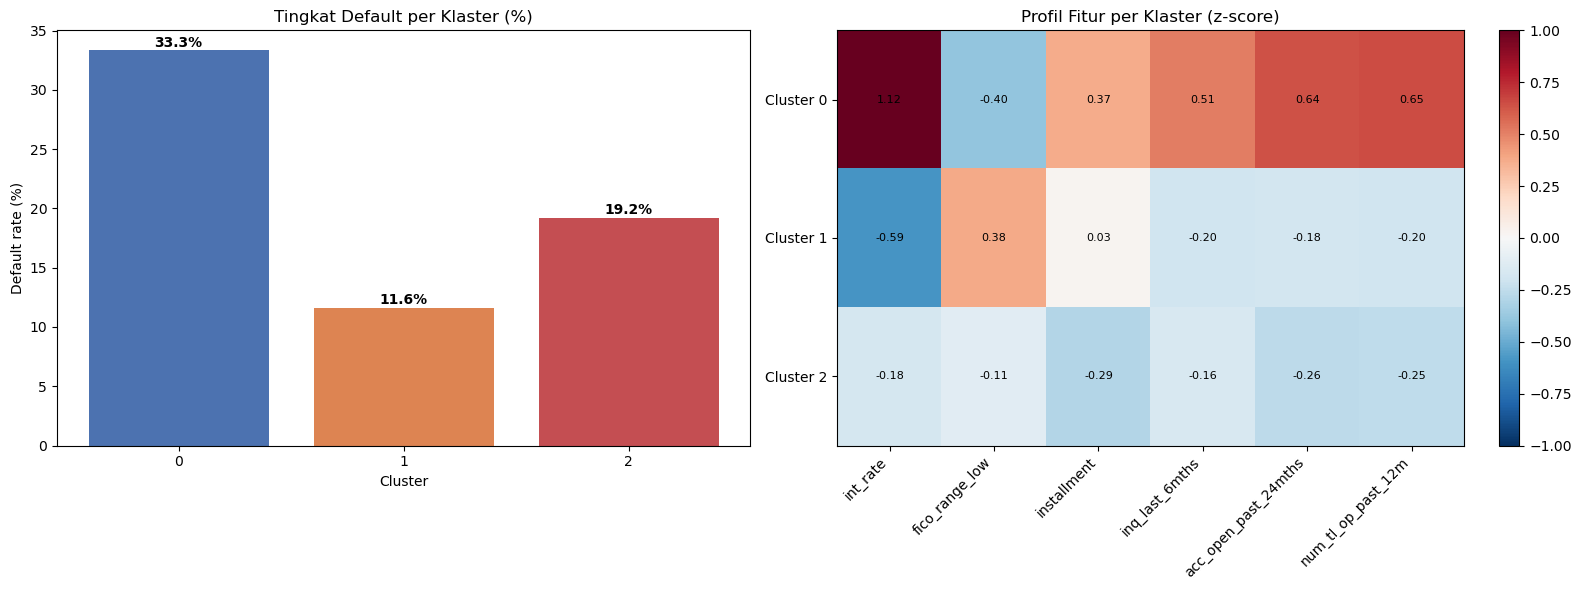

In [24]:
# Dua panel pendukung: tingkat default per klaster dan profil fitur (heatmap).
# Visualisasi sebaran klaster PCA kami pindahkan ke sel 3D interaktif di bawah.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) Default rate per cluster
dr = (df_clean.groupby('Cluster_Label')['loan_status_binary'].mean() * 100).sort_index()
bars = axes[0].bar(dr.index.astype(str), dr.values, color=['#4C72B0', '#DD8452', '#C44E52'])
axes[0].set_title('Tingkat Default per Klaster (%)')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Default rate (%)')
for b, v in zip(bars, dr.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# (2) Feature profile heatmap (z-score means)
prof = df_clean.groupby('Cluster_Label')[profile_features].mean()
im = axes[1].imshow(prof.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(profile_features)))
axes[1].set_xticklabels(profile_features, rotation=45, ha='right')
axes[1].set_yticks(range(len(prof.index)))
axes[1].set_yticklabels([f'Cluster {i}' for i in prof.index])
axes[1].set_title('Profil Fitur per Klaster (z-score)')
for (r, cc), val in np.ndenumerate(prof.values):
    axes[1].text(cc, r, f'{val:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

### Sebaran Klaster dalam PCA 3D (Interaktif)

Kami memproyeksikan ke-14 fitur ke tiga komponen utama (PC1, PC2, PC3) lalu menampilkannya
sebagai scatter 3D interaktif dengan Plotly. Berbeda dari proyeksi 2D, versi tiga dimensi ini
bisa kami putar dan perbesar, sehingga struktur klaster yang tumpang tindih di 2D bisa kami
periksa dari berbagai sudut. Kami tetap memakai sampel agar plot ringan namun representatif.

In [25]:
import plotly.express as px
from sklearn.decomposition import PCA

# Proyeksi PCA 3 komponen pada sampel (variabel viz sama seperti sebelumnya)
np.random.seed(42)
viz_idx = np.random.choice(X_scaled.shape[0], 20000, replace=False)
X_viz = X_scaled[viz_idx]
labels_viz = df_clean['Cluster_Label'].values[viz_idx]

pca3d = PCA(n_components=3, random_state=42)
X_pca3 = pca3d.fit_transform(X_viz)
ve3 = pca3d.explained_variance_ratio_

pca_df = pd.DataFrame({
    'PC1': X_pca3[:, 0],
    'PC2': X_pca3[:, 1],
    'PC3': X_pca3[:, 2],
    'Cluster': [f'Cluster {c}' for c in labels_viz],
})

fig3d = px.scatter_3d(
    pca_df, x='PC1', y='PC2', z='PC3', color='Cluster',
    opacity=0.5,
    title=f'Sebaran Klaster (PCA 3D) - Total varians dijelaskan: {ve3.sum()*100:.1f}%',
    labels={
        'PC1': f'PC1 ({ve3[0]*100:.1f}%)',
        'PC2': f'PC2 ({ve3[1]*100:.1f}%)',
        'PC3': f'PC3 ({ve3[2]*100:.1f}%)',
    },
)
fig3d.update_traces(marker=dict(size=2))

fig3d.update_layout(
    autosize=False,
    width=650, height=500,
    margin=dict(l=0, r=0, t=40, b=0),
    legend=dict(itemsizing='constant'),
    scene=dict(
        aspectmode='cube',
        aspectratio=dict(x=0.7, y=0.7, z=0.7),
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.6)),
    ),
)
fig3d.show()

print(f"PC1 + PC2 + PC3 menjelaskan {ve3.sum()*100:.1f}% varians "
      f"(2D sebelumnya hanya {ve3[:2].sum()*100:.1f}%).")

PC1 + PC2 + PC3 menjelaskan 46.5% varians (2D sebelumnya hanya 34.5%).


**Analisis Hasil (dua panel pendukung + PCA 3D):**

Panel default rate menjadi bukti validasi eksternal yang paling kuat. Tingkat default naik monoton dengan jarak lebar, yaitu 11,7% pada Cluster 0, 19,2% pada Cluster 1, dan 33,4% pada Cluster 2, padahal loan_status_binary tidak pernah dipakai sebagai input clustering. Artinya, meski klaster tampak membaur pada proyeksi PCA, ketiganya tetap memisahkan tingkat risiko nyata secara tegas.

Panel heatmap menjelaskan penyebab perbedaan risiko tersebut, dan polanya konsisten secara bisnis. Cluster 2 memiliki suku bunga sangat tinggi (z = +1,12), FICO rendah (−0,40), serta aktivitas kredit agresif (inquiry +0,52, akun baru +0,64, trade line baru +0,65), sebuah profil khas peminjam berisiko tinggi. Cluster 0 menunjukkan kebalikannya dengan bunga rendah (−0,59) dan FICO tinggi (+0,38) sebagai profil peminjam prima, sementara Cluster 1 berada di antara keduanya dengan mayoritas fitur mendekati rata-rata.

Scatter PCA 3D melengkapi kedua panel di atas dengan gambaran spasial. Ketiga komponen utama hanya menjelaskan sekitar 46,5% varians total (PC1 20,3%, PC2 14,1%, dan PC3 12,0%), sehingga lebih dari separuh informasi tetap tidak tertangkap meski sudah ditambah dimensi ketiga. Ketiga klaster menempati wilayah yang berbeda, namun batas antar warna membaur tanpa celah kosong, yang secara visual mengonfirmasi Silhouette rendah serta sifat data kredit yang gradual. Sebagian overlap ini merupakan konsekuensi dari varians yang tidak tervisualisasi, sehingga pemisahan di ruang fitur penuh kemungkinan lebih baik daripada yang terlihat. Keunggulan versi 3D interaktif adalah kami bisa memutar plot untuk memastikan wilayah klaster memang berbeda, bukan sekadar tumpang tindih akibat sudut pandang tertentu.

Kesimpulannya, scatter PCA mengakui Silhouette yang rendah secara terbuka, tetapi bar default rate dan heatmap membuktikan ketiga klaster terstratifikasi jelas berdasarkan risiko sekaligus memiliki profil fitur yang berbeda dan masuk akal. Pembeda terkuatnya adalah int_rate dan fico_range_low, dengan pola konsisten bahwa kombinasi bunga tinggi dan FICO rendah menghasilkan default tertinggi. Temuan ini mendukung K=3 sebagai segmentasi yang bermakna secara bisnis meskipun metrik geometris internalnya lemah.

## 9. Insight per Tahun (Analisis Tren Temporal)

Kolom `issue_year` (digabungkan dari `issue_year_accepted.parquet` di Bagian 6b-lanjutan) memungkinkan analisis tren: apakah bauran klaster dan tingkat risiko berubah dari waktu ke waktu, dan apakah stratifikasi risiko K=3 tetap valid di setiap periode.

Baris tanpa tahun setelah merge: 0


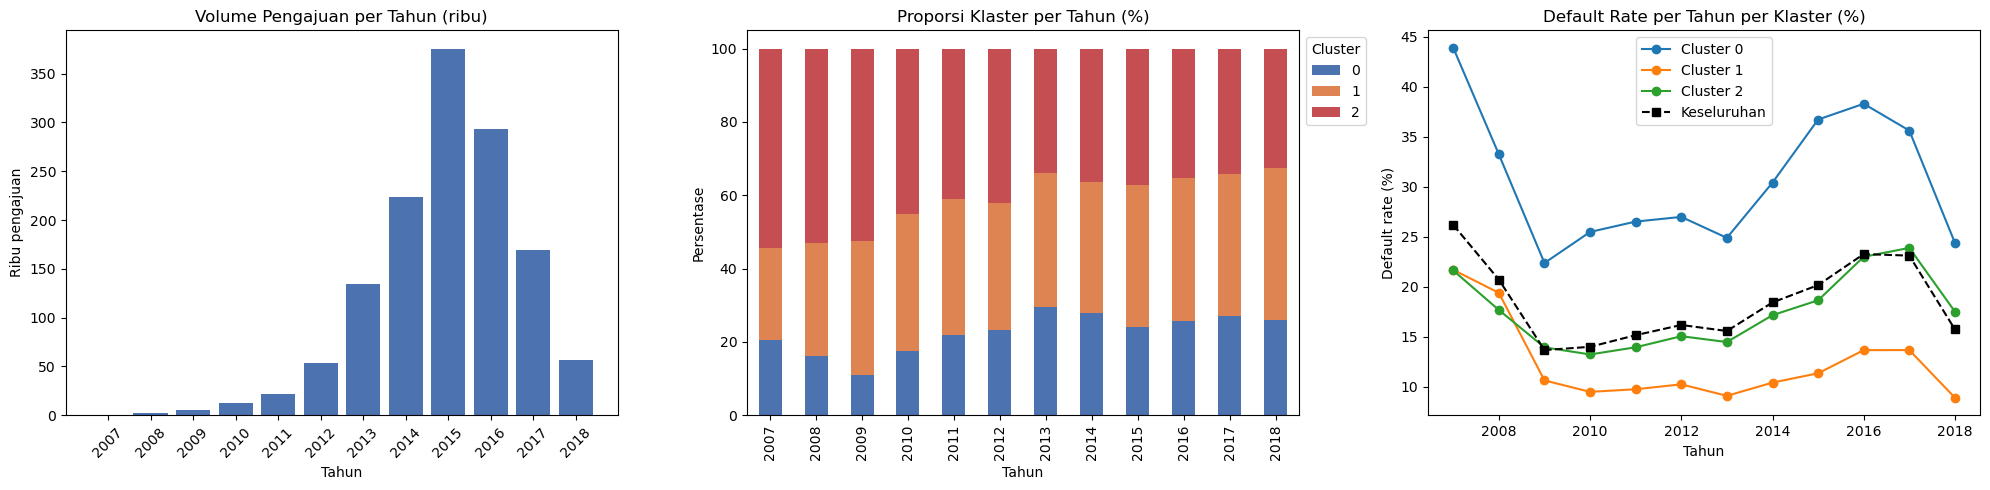

Proporsi klaster per tahun (%):


Cluster_Label,0,1,2
issue_year,,,
2007,20.4,25.2,54.4
2008,16.1,31.0,52.9
2009,11.1,36.4,52.5
2010,17.6,37.3,45.1
2011,22.0,37.0,41.0
2012,23.3,34.5,42.1
2013,29.5,36.6,33.8
2014,27.8,35.8,36.4
2015,24.1,38.7,37.2



Default rate per tahun per klaster (%):


Cluster_Label,0,1,2
issue_year,,,
2007,43.90,21.71,21.65
2008,33.25,19.41,17.69
2009,22.39,10.65,13.96
2010,25.50,9.51,13.25
2011,26.53,9.77,13.97
2012,27.00,10.26,15.08
2013,24.91,9.12,14.49
2014,30.43,10.44,17.18
2015,36.73,11.37,18.66


In [26]:
# --- Insight tren temporal: gabungkan kolom tahun ke df_clean untuk analisis per tahun ---
# 'df_year' sudah dimuat di Bagian 6b (lanjutan); di sini digabung ke df_clean (bukan hanya
# labels_out) agar bisa dianalisis bersama loan_status_binary & Cluster_Label.
df_clean = df_clean.merge(df_year, on='orig_row_pos', how='left')
print(f"Baris tanpa tahun setelah merge: {df_clean['issue_year'].isna().sum()}")

vol_year = df_clean['issue_year'].value_counts().sort_index()
prop_year = pd.crosstab(df_clean['issue_year'], df_clean['Cluster_Label'], normalize='index') * 100
dr_year = df_clean.groupby('issue_year')['loan_status_binary'].mean() * 100
dr_year_cl = (df_clean.groupby(['issue_year', 'Cluster_Label'])['loan_status_binary'].mean() * 100).unstack()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].bar(vol_year.index.astype(str), vol_year.values / 1000, color='#4C72B0')
axes[0].set_title('Volume Pengajuan per Tahun (ribu)')
axes[0].set_xlabel('Tahun'); axes[0].set_ylabel('Ribu pengajuan')
axes[0].tick_params(axis='x', rotation=45)

prop_year.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#DD8452', '#C44E52'])
axes[1].set_title('Proporsi Klaster per Tahun (%)')
axes[1].set_xlabel('Tahun'); axes[1].set_ylabel('Persentase')
axes[1].legend(title='Cluster', loc='upper left', bbox_to_anchor=(1, 1))

for cl in dr_year_cl.columns:
    axes[2].plot(dr_year_cl.index, dr_year_cl[cl], marker='o', label=f'Cluster {cl}')
axes[2].plot(dr_year.index, dr_year.values, marker='s', linestyle='--', color='black', label='Keseluruhan')
axes[2].set_title('Default Rate per Tahun per Klaster (%)')
axes[2].set_xlabel('Tahun'); axes[2].set_ylabel('Default rate (%)')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Proporsi klaster per tahun (%):")
display(prop_year.round(1))
print("\nDefault rate per tahun per klaster (%):")
display(dr_year_cl.round(2))

**Interpretasi Insight per Tahun:**

1. **Volume pengajuan melonjak lalu menurun.** Dari 603 pengajuan (2007) naik ke puncak 375.546 (2015), lalu turun ke 293.105 (2016), 169.321 (2017), dan 56.318 (2018) -- mencerminkan pertumbuhan pesat LendingClub hingga pertengahan dekade 2010-an, diikuti perlambatan/pengetatan pada 2016-2018. Angka 2018 kemungkinan juga terpotong karena cakupan dataset tidak mencakup satu tahun penuh.
2. **Bauran risiko bergeser makin berisiko seiring waktu.** Proporsi Cluster 2 (High-Risk) turun dulu dari 20,4% (2007) ke titik terendah 11,1% (2009), lalu naik cukup konsisten menjadi kisaran 24-29% sepanjang 2013-2018 -- hampir dua kali lipat dari titik terendahnya. Ini mengindikasikan bauran peminjam platform bergeser ke arah risiko lebih tinggi seiring skala bisnis membesar.
3. **Default rate keseluruhan mengikuti pola serupa**, terendah di 2009-2010 (~13,7-14,0%), naik bertahap ke puncak 23,29% (2016), lalu turun tajam ke 15,76% di 2018. Penurunan di 2018 kemungkinan besar adalah artefak *right-censoring* (pinjaman yang diterbitkan 2018 belum cukup waktu untuk jatuh tempo/gagal bayar saat data diambil), bukan perbaikan kualitas kredit riil -- perlu dibaca dengan hati-hati, bukan sebagai tren positif.
4. **Stratifikasi risiko K=3 stabil sepanjang waktu.** Urutan risiko antar klaster (Cluster 0 < Cluster 1 < Cluster 2) konsisten di SETIAP tahun tanpa pengecualian: default rate Cluster 2 selalu tertinggi (berkisar 22,3%-43,9%) dan Cluster 0 selalu terendah (8,9%-21,7%). Ini memperkuat validitas segmentasi K=3 -- pembeda risiko yang ditemukan bukan kebetulan satu periode, melainkan pola yang bertahan sepanjang 2007-2018, sekaligus menjadi bukti tambahan (di luar Bagian 6e) bahwa klaster ini layak dipakai untuk keputusan bisnis jangka panjang, bukan hanya snapshot satu titik waktu.

### 9a. Insight per RENTANG Tahun (Bukan Hanya Satu Tahun)

Tabel di atas memecah data per satu tahun. Pertanyaan yang lebih relevan untuk dashboard Fase 5: bisakah datanya difilter ke RENTANG bebas, mis. 2010-2012 atau 2009-2015, bukan cuma satu tahun sekaligus? Sel di bawah membuktikannya secara langsung dengan sebuah fungsi yang menerima `(tahun_awal, tahun_akhir)` bebas.

In [27]:
# --- Insight per RENTANG tahun bebas (bukan cuma satu tahun) ---
# issue_year tersimpan per-baris (satu nilai per pengajuan), bukan sudah dikelompokkan ke
# bin tetap, sehingga bisa difilter ke rentang mana pun -- inilah yang membuat kolom ini
# siap dipakai Fase 5 untuk filter rentang interaktif (mis. slider dua-ujung).
def cluster_summary_for_year_range(df, y0, y1):
    sub = df[(df['issue_year'] >= y0) & (df['issue_year'] <= y1)]
    prop = sub['Cluster_Label'].value_counts(normalize=True).sort_index() * 100
    dr = sub.groupby('Cluster_Label')['loan_status_binary'].mean() * 100
    dr_all = sub['loan_status_binary'].mean() * 100
    return len(sub), prop, dr, dr_all

# 4 contoh rentang mengikuti era pertumbuhan platform (Bagian 9) + 1 rentang BEBAS (custom,
# 2009-2015) yang sengaja memotong lintas beberapa era untuk membuktikan fungsinya tidak
# terpaku pada bin tetap -- persis seperti contoh rentang bebas yang diminta (mis. 2009-2015).
example_ranges = [
    (2007, 2009, 'Awal & titik terendah risiko'),
    (2010, 2012, 'Masa pemulihan pasca krisis'),
    (2013, 2015, 'Puncak pertumbuhan volume'),
    (2016, 2018, 'Perlambatan & tightening'),
    (2009, 2015, 'Rentang BEBAS (custom, lintas beberapa era di atas)'),
]

rows = []
for y0, y1, label in example_ranges:
    n, prop, dr, dr_all = cluster_summary_for_year_range(df_clean, y0, y1)
    for cl in sorted(prop.index):
        rows.append({
            'rentang': f'{y0}-{y1}',
            'keterangan': label,
            'n_baris': n,
            'klaster': name_map[cl],
            'proporsi_%': round(prop[cl], 1),
            'default_rate_%': round(dr[cl], 2),
        })
    rows.append({
        'rentang': f'{y0}-{y1}', 'keterangan': label, 'n_baris': n,
        'klaster': 'KESELURUHAN', 'proporsi_%': 100.0, 'default_rate_%': round(dr_all, 2),
    })

range_summary_df = pd.DataFrame(rows)
display(range_summary_df)

,rentang,keterangan,n_baris,klaster,proporsi_%,default_rate_%
0,2007-2009,Awal & titik terendah risiko,8277,High-Risk Borrowers,13.2,28.64
1,2007-2009,Awal & titik terendah risiko,8277,Prime / Low-Risk Borrowers,34.0,13.56
2,2007-2009,Awal & titik terendah risiko,8277,Moderate-Risk Borrowers,52.7,15.62
3,2007-2009,Awal & titik terendah risiko,8277,KESELURUHAN,100.0,16.64
4,2010-2012,Masa pemulihan pasca krisis,87625,High-Risk Borrowers,22.2,26.72
5,2010-2012,Masa pemulihan pasca krisis,87625,Prime / Low-Risk Borrowers,35.5,10.03
6,2010-2012,Masa pemulihan pasca krisis,87625,Moderate-Risk Borrowers,42.3,14.53
7,2010-2012,Masa pemulihan pasca krisis,87625,KESELURUHAN,100.0,15.63
8,2013-2015,Puncak pertumbuhan volume,733453,High-Risk Borrowers,26.2,32.25
9,2013-2015,Puncak pertumbuhan volume,733453,Prime / Low-Risk Borrowers,37.5,10.69


**Interpretasi:** Rentang custom 2009-2015 (5 baris terakhir) menggabungkan >800 ribu pengajuan lintas beberapa era sekaligus, dan hasilnya tetap masuk akal -- proporsi High-Risk Borrowers (25,6%) dan default rate keseluruhan (18,44%) berada tepat di antara nilai era 2010-2012 dan 2013-2015, sesuai proporsi tahun yang tercakup di dalamnya. Ini membuktikan `cluster_summary_for_year_range()` bekerja untuk RENTANG bebas apa pun (bukan hanya 4 era contoh di atas), sehingga kolom `issue_year` pada `Results/cluster_labels_accepted.parquet` sudah siap dipakai Fase 5 untuk filter rentang interaktif (mis. slider dua-ujung 2007-2018), bukan hanya dropdown satu tahun.

## 10. Call To Action (Rekomendasi Bisnis)

Berdasarkan tiga klaster risiko (Bagian 6-7) dan tren temporal (Bagian 9) di atas, berikut rekomendasi aksi bisnis konkret per segmen:

**Cluster 2 -- High-Risk Borrowers (25,78% populasi, default rate 33,37%)**
- Repricing bertingkat: pertimbangkan tambahan premi bunga untuk sub-segmen dengan `fico_range_low` terendah *di dalam* klaster ini, bukan tarif rata di seluruh klaster.
- Mitigasi risiko: syaratkan jaminan tambahan atau batasi plafon pinjaman maksimum untuk klaster ini.
- Monitoring berkala: proporsi klaster ini naik dari titik terendah 11,1% (2009) menjadi 24-29% (2013-2018) -- tim risk perlu meninjau ulang kebijakan underwriting secara periodik, bukan sekali di awal, karena bauran risiko platform terbukti bergeser dari waktu ke waktu.

**Cluster 1 -- Moderate-Risk Borrowers (36,23% populasi, default rate 19,19%)**
- Program insentif pembayaran tepat waktu (mis. penurunan bunga di tahun kedua bila tidak ada keterlambatan) untuk mendorong migrasi profil nasabah ke arah Cluster 0.

**Cluster 0 -- Prime / Low-Risk Borrowers (37,99% populasi, default rate 11,65%)**
- Program retensi & cross-sell: tawarkan pinjaman tambahan/refinancing dengan bunga kompetitif -- risiko rendah dan potensi loyalitas tinggi membuat segmen ini paling menguntungkan untuk dipertahankan.
- Fast-track approval untuk pengajuan berikutnya dari nasabah existing di klaster ini.

**Lintas tahun**
- Default rate 2018 (15,76%) kemungkinan besar under-estimate akibat *right-censoring* (Bagian 9, insight #3). Kalibrasi ulang model risiko sebaiknya memakai cohort yang sudah matang (>=2 tahun sejak `issue_year`), bukan tahun-tahun terbaru mentah-mentah.

**Untuk Fase 5 (Dashboard)**
- Kolom `issue_year`/`issue_month` sudah tersedia di `Results/cluster_labels_accepted.parquet` (Bagian 6b-lanjutan) -- gunakan untuk menyediakan filter tahun, sehingga tim risk bisa memantau pergeseran bauran klaster (insight #2, Bagian 9) secara berkala, bukan hanya snapshot seluruh periode 2007-2018 sekaligus.